In [25]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------- ----------------- 4.5/8.1 MB 24.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 21.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 24.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 16.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


### Naive Solution

In [27]:
import numpy as np
import time

def hadamard_matrix(n):
    assert (n & (n - 1)) == 0, "n must be power of 2"
    H = np.array([[1]])
    while H.shape[0] < n:
        H = np.block([[H, H], [H, -H]]) / np.sqrt(2)
    return H

# testing with rank 4 hadamard matrix
start = time.perf_counter()
H4 = hadamard_matrix(4)

a = np.array([1.0, 2.0, 3.0, 4.0])

result = np.round(np.dot(H4, a))
end = time.perf_counter()


print("hadamard matrix:")
print(H4)
print("hadamard transform result", result)
print("time: ", end-start)


hadamard matrix:
[[ 0.5  0.5  0.5  0.5]
 [ 0.5 -0.5  0.5 -0.5]
 [ 0.5  0.5 -0.5 -0.5]
 [ 0.5 -0.5 -0.5  0.5]]
hadamard transform result [ 5. -1. -2.  0.]
time:  0.00043690018355846405


### Butterfly Network Solution

In [28]:
import math

def fwht(a) -> None:
    assert math.log2(len(a)).is_integer(), "must be the power of 2"
    h = 1
    while h < len(a):
        # perform FWHT
        for i in range(0, len(a), h * 2):
            for j in range(i, i + h):
                x = a[j]
                y = a[j + h]

                # butterfly network core computation
                a[j] = x + y
                a[j + h] = x - y

        # normalize
        a /= math.sqrt(2)
        h *= 2

a = np.array([1.0, 2.0, 3.0, 4.0])

print("Original array:", a)

start = time.perf_counter()
fwht(a)
end = time.perf_counter()

print("Transformed array:", a)
print("time: ", end-start)

Original array: [1. 2. 3. 4.]
Transformed array: [ 5. -1. -2.  0.]
time:  0.00013570021837949753


### More tests

In [ ]:
# testing size 2 to 4096

x = np.array([2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192])
y1 = np.zeros(13) # naive hadamard construction + mat mul
y2 = np.zeros(13) # fwht + butterfly network simulation

for i in range(13): 
    cur_size = x[i]
    print("current size: ", cur_size)
    
    v = np.random.rand(cur_size, 1)
    
    t1 = time.perf_counter()
    
    h = hadamard_matrix(cur_size)
    result = np.round(np.dot(h, v))
    
    t2 = time.perf_counter()
    
    fwht(v) # in place fwht
    
    t3 = time.perf_counter()
    
    y1[i] = t2-t1
    y2[i] = t3-t2
    
    
    print("- naive approach time: ", t2-t1)
    print("- fwht + butterfly network time: ", t3-t2)  
    # print("- accurate?: ", np.allclose(result, v, atol=1e-6))
    print("- speed-up: ", (t2-t1)/(t3-t2))
    
    

current size:  2
- naive approach time:  0.018268299754709005
- fwht + butterfly network time:  0.0001004999503493309
- accurate?:  False
- speed-up:  181.77421671562678
current size:  4
- naive approach time:  0.00037160003557801247
- fwht + butterfly network time:  9.63001511991024e-05
- accurate?:  False
- speed-up:  3.8587689733707924
current size:  8
- naive approach time:  0.00036740023642778397
- fwht + butterfly network time:  0.0001146998256444931
- accurate?:  False
- speed-up:  3.2031455528670487
current size:  16
- naive approach time:  0.0003912001848220825
- fwht + butterfly network time:  0.00034239981323480606
- accurate?:  False
- speed-up:  1.142524527470495
current size:  32
- naive approach time:  0.0006413999944925308
- fwht + butterfly network time:  0.000602200161665678
- accurate?:  False
- speed-up:  1.065094357860062
current size:  64
- naive approach time:  0.0014522001147270203
- fwht + butterfly network time:  0.0013435999862849712
- accurate?:  False
- spe

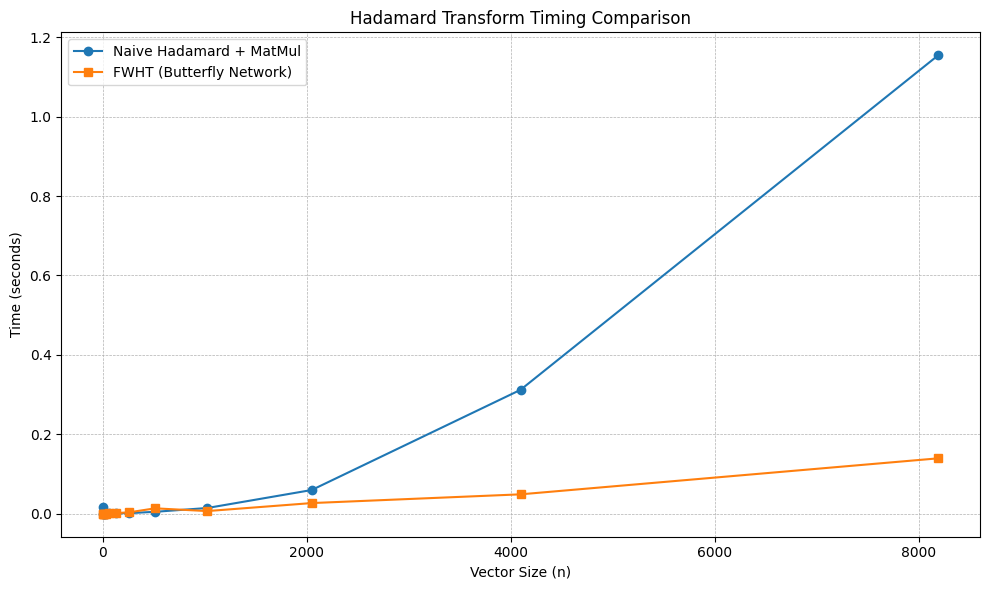

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(x, y1, marker='o', label='Naive Hadamard + MatMul')
plt.plot(x, y2, marker='s', label='FWHT (Butterfly Network)')

# plt.xscale('log', base=2) 
# plt.yscale('log')  
plt.xlabel('Vector Size (n)')
plt.ylabel('Time (seconds)')
plt.title('Hadamard Transform Timing Comparison')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()